# Random Sample Imputation

This notebook demonstrates **Random Sample Imputation** for handling missing values in the `Age` column of the Titanic dataset. We compare the original and imputed distributions to verify that the imputation preserves the data distribution better than mean/median imputation.


In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

## Inspect the dataset
Load only the columns required for this demonstration (`Age`, `Fare`, and `Survived`).

In [35]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

## Check missing values
`df.isnull().mean()*100` returns the **percentage of missing values** in each column. Here, only `Age` contains missing values (~20%).

In [37]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

## Train-Test Split
Always split the data **before** performing imputation to avoid data leakage. The imputer should learn only from the training data.

In [39]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [40]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [41]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


## Create a copy for imputation
`Age_imputed` preserves the original `Age` column so we can compare the distributions before and after imputation.

X_train['Age'].isnull().sum() this give the number of missing values for Age in the dataset
sample(n) gives n random values from the dataset

## Random Sample Imputation
For every missing age, randomly sample an existing (non-missing) age from the **training set**. This helps preserve the original distribution and variance.

> **Note:** Modern pandas recommends using `.loc[...]` instead of chained assignment to avoid warnings.

In [42]:
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age']
    .dropna()
    .sample(X_train['Age'].isnull().sum())
    .values
)

X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age']
    .dropna()
    .sample(X_test['Age'].isnull().sum())
    .values
)

In [43]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([19. , 60. , 30. , 28. , 33. , 39. , 28. , 27. , 14. , 23. , 58. ,
        8. , 33. , 25. ,  9. , 34. , 29. , 25. , 23. , 54. , 48. , 38. ,
        2. , 17. , 49. , 38. , 19. , 15. , 28.5, 30. , 18. , 14. , 31. ,
       21. , 30. , 25. , 16. , 28. ,  3. , 64. , 28. ,  4. , 21. , 21. ,
       51. , 29. , 18. , 58. , 66. , 37. , 19. , 28. ,  6. , 14. , 18. ,
       24. , 11. , 32. , 26. ,  4. , 22. , 24. , 19. , 14. , 43. , 39. ,
       40. , 61. , 41. , 18. , 57. , 35. , 22. , 24. , 31. , 23. , 56. ,
       40. , 46. , 27. ,  4. , 16. ,  5. , 45. , 43. , 34. , 36. , 50. ,
       33. , 28. , 33. , 32. , 30. , 22. , 16. , 51. , 30. , 47. , 27. ,
       30. , 34. , 20. , 54. , 30. , 17. , 23. , 36. , 47. ,  3. , 31. ,
       25. ,  3. , 50. , 35. , 39. ,  8. , 21. , 33. , 28. , 42. , 34. ,
       47. , 29. , 62. , 19. , 16. , 19. , 23. , 23. , 27. , 29. , 22. ,
        4. , 16. , 25. , 39. , 19. , 26. , 40. , 45. , 30. , 28. , 27. ,
       30. , 32. , 25. , 30. , 33. ])

In [44]:
X_train['Age'].isnull().sum()

np.int64(148)

In [45]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,31.0
493,71.0,49.5042,71.0
527,NaN,221.7792,24.0


## Compare Distributions
Overlay the original and imputed distributions. If the curves are very similar, the imputation has successfully preserved the statistical properties of the feature.

C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[

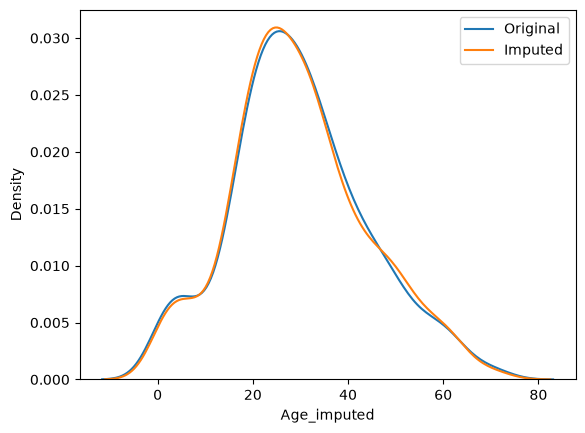

In [46]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [47]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  202.9664712920163


In [48]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,53.866625
Age,71.512440,204.349513,204.349513
Age_imputed,53.866625,204.349513,202.966471


<Axes: >

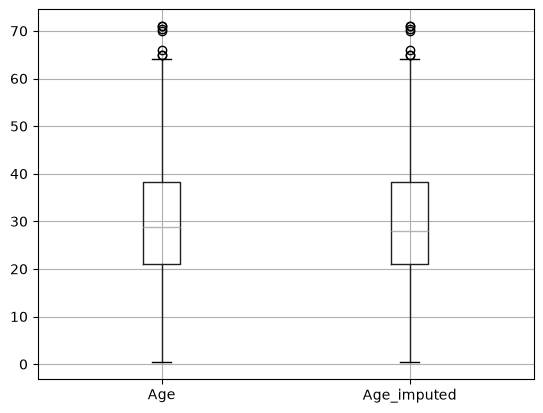

In [49]:
X_train[['Age', 'Age_imputed']].boxplot()

In [50]:
#sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))
#This random state is used to generate the same random number for the same observation

In [51]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [52]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [53]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [54]:
X = data
y = data['SalePrice']

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [56]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [57]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1303,NaN,TA,232000,TA,NaN
1344,TA,TA,155835,TA,TA
1103,Fa,TA,159500,TA,Fa
72,TA,TA,185000,TA,TA
558,TA,TA,175000,TA,TA


In [58]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\856878696.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\856878696.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update th

In [59]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [60]:
temp

,original,imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [61]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.338945
TA,0.412439,0.282828
Fa,0.040917,0.028058
Po,0.027823,0.019080
Ex,0.024550,0.016835


C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

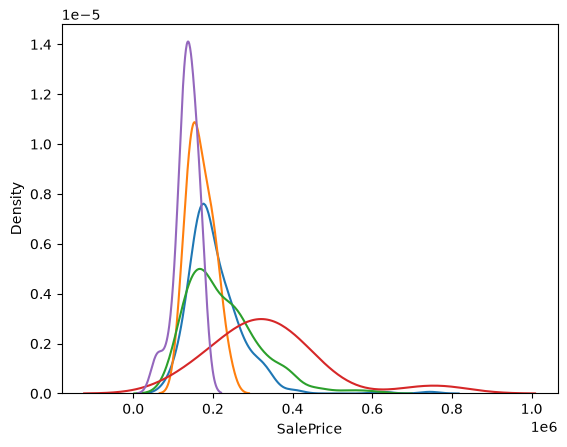

In [62]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\sujat\AppData\Local\Temp\ipykernel_11932\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29

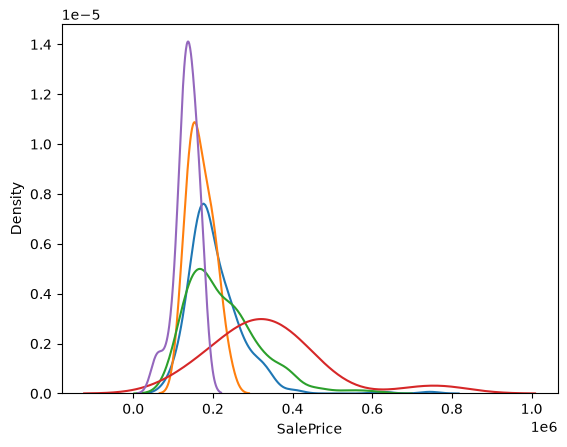

In [63]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()